<a href="https://colab.research.google.com/github/ritiksharmasde/Deep_Learning/blob/main/resnet_chestXray.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/dataset"

In [ ]:
# chest xray on resnet50 using transfer learning ,

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import time

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("GPU:", tf.config.list_physical_devices('GPU'))

DATASET_PATH = "/content/drive/MyDrive/chestxray/dataset"

IMG_SIZE = (224,224)
BATCH_SIZE = 16
EPOCHS = 10

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH + "/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH + "/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x,y:(preprocess_input(x),y)).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x,y:(preprocess_input(x),y)).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x,y:(preprocess_input(x),y)).prefetch(AUTOTUNE)

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    ModelCheckpoint("best_resnet.keras", save_best_only=True, monitor="val_accuracy"),
    EarlyStopping(patience=3, restore_best_weights=True)
]

start = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Training time (min):", (time.time()-start)/60)

model = tf.keras.models.load_model("best_resnet.keras")

# ================= METRICS =================
y_true, y_pred, y_prob = [], [], []

for images, labels in test_ds:
    preds = model.predict(images)
    y_prob.extend(preds)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

cm = confusion_matrix(y_true, y_pred)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr")

print("\n===== RESULTS =====")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 6478 files belonging to 3 classes.
Found 1188 files belonging to 3 classes.
Found 1193 files belonging to 3 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Epoch 1/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 1900s 5s/step - accuracy: 0.8603 - loss: 0.3625 - val_accuracy: 0.9259 - val_loss: 0.1897
Epoch 2/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 53s 130ms/step - accuracy: 0.9153 - loss: 0.2220 - val_accuracy: 0.9293 - val_loss: 0.1749
Epoch 3/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 50s 123ms/step - accuracy: 0.9247 - loss: 0.1977 - val_accuracy: 0.9209 - val_loss: 0.1928
Epoch 4/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 52s 129ms/step - accuracy: 0.9304 - loss: 0.1725 - val_accuracy: 0.9453 - val_loss: 0.1401
Epoch 5/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 51s 125ms/step - accuracy: 0.9432 - loss: 0.1480 - val_accuracy: 0.9545 - val_loss: 0.1222
Epoch 6/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 81s 123ms/step - accuracy: 0.9517 - loss: 0.1268 - val_accur

In [17]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input

model = tf.keras.models.load_model("best_resnet.keras")

# Build model once
_ = model(tf.zeros((1, 224, 224, 3)))

resnet_layer = model.get_layer("resnet50")
last_conv_layer_name = "conv5_block3_out"

def get_img_array(img_path, size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    arr = tf.keras.preprocessing.image.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    return preprocess_input(arr)

def make_gradcam_heatmap(img_array):
    grad_model = tf.keras.models.Model(
        inputs=resnet_layer.input,
        outputs=[resnet_layer.get_layer(last_conv_layer_name).output, resnet_layer.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, resnet_output = grad_model(img_array)
        x = model.layers[1](resnet_output)
        x = model.layers[2](x)
        x = model.layers[3](x, training=False)
        predictions = model.layers[4](x)

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if max_val == 0:
        return heatmap.numpy(), predictions

    heatmap = heatmap / max_val
    return heatmap.numpy(), predictions

def display_gradcam(img_path):
    img_array = get_img_array(img_path)
    heatmap, predictions = make_gradcam_heatmap(img_array)

    pred_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0])

    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + img
    superimposed_img = np.uint8(superimposed_img)

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original X-ray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Grad-CAM | Pred: {class_names[pred_class]} ({confidence:.2f})")
    plt.axis("off")

    plt.show()

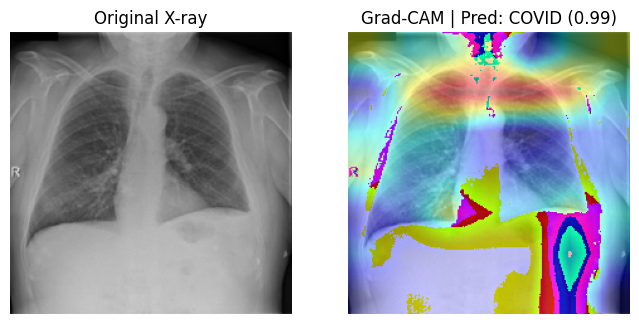

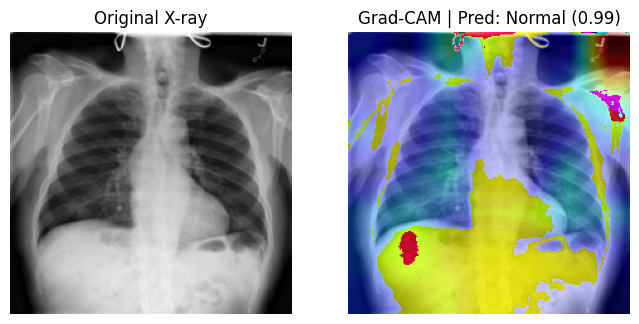

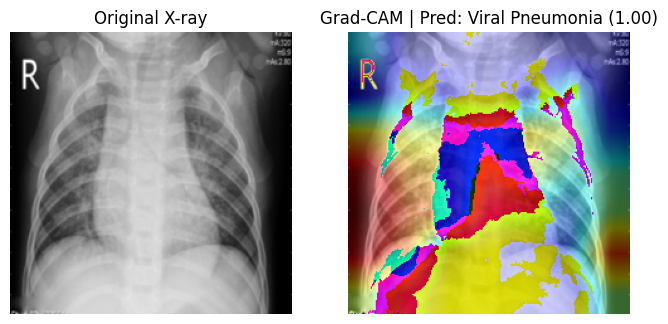

In [19]:
display_gradcam("/content/drive/MyDrive/chestxray/dataset/test/COVID/COVID-3070.png")
display_gradcam("/content/drive/MyDrive/chestxray/dataset/test/Normal/Normal-3516.png")
display_gradcam("/content/drive/MyDrive/chestxray/dataset/test/Viral Pneumonia/Viral Pneumonia-1338.png")